# 🧠 Knowledge Structure & LLM Reasoning Quality
## Notebook 1 — Simulation Experiment (Monte Carlo)

---

**Article:** *From Data to Knowledge: Why Knowledge Graphs and Network Science Are a Likely Foundation of More Reliable AI*  
**Method:** Monte Carlo simulation — no live LLM calls required  
**Domain:** Synthetic Biomedical (Drug → Mechanism → Disease)

---

### What this notebook does

This notebook tests a central hypothesis: **structured knowledge (a Knowledge Graph) leads to measurably better LLM reasoning than the same information as unstructured plain text.**

Since this is a simulation, it models the *information retrieval constraints* of each condition:
- **Plain Text condition:** facts are shuffled → probability of retrieving a full multi-hop chain degrades with each hop
- **Knowledge Graph condition:** relationships are explicit → multi-hop paths are always navigable

Three metrics are measured:
| Metric | What it measures |
|---|---|
| **Keyword Recall** | Fraction of expected answer concepts retrieved |
| **Hallucination Rate** | Irrelevant concepts introduced per question |
| **Reasoning Depth** | Heuristic completeness of reasoning chain |

---

> ⚠️ **Transparency note:** This is a *simulation-based* experiment. LLM responses are modeled probabilistically, not generated by a real model. For the live LLM experiment (Claude Sonnet 4.6 + GPT-4o), see **Notebook 2**.

---

**Code & article:** `github.com/mfbscience/knowledge-graph-llm-experiment`

## ⚙️ Section 1 — Install Dependencies

In [ ]:
# All dependencies are available in Colab by default.
# NetworkX may need upgrading for the community detection API used here.
!pip install -q --upgrade networkx
print('✓ Dependencies ready.')

✓ Dependencies ready.


## 📚 Section 2 — Imports

In [ ]:
import json
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms.community import greedy_modularity_communities

random.seed(42)
np.random.seed(42)
print('✓ Imports OK')

✓ Imports OK


## 🗄️ Section 3 — Synthetic Knowledge Base

We define a biomedical knowledge base of **34 triples** across 21 entities.

Each triple has the form: `(Subject) --[relation]--> (Object)`

The domain covers:
- **Drugs:** Aspirin, Ibuprofen, Celecoxib, Metformin, Atorvastatin
- **Mechanisms:** COX1, COX2, AMPK, mTOR, HMG-CoA Reductase, Prostaglandins
- **Conditions:** Inflammation, Pain, Cardiovascular Disease, Type 2 Diabetes, Gastric Ulcer

In [ ]:
TRIPLES = [
    ("Aspirin",        "inhibits",             "COX1"),
    ("Aspirin",        "inhibits",             "COX2"),
    ("Ibuprofen",      "inhibits",             "COX1"),
    ("Ibuprofen",      "inhibits",             "COX2"),
    ("Metformin",      "activates",            "AMPK"),
    ("Metformin",      "inhibits",             "mTOR"),
    ("Atorvastatin",   "inhibits",             "HMG-CoA_Reductase"),
    ("Celecoxib",      "selectively_inhibits", "COX2"),
    ("COX1",           "produces",             "Prostaglandins"),
    ("COX2",           "produces",             "Prostaglandins"),
    ("COX2",           "mediates",             "Inflammation"),
    ("Prostaglandins", "cause",                "Inflammation"),
    ("Prostaglandins", "cause",                "Pain"),
    ("AMPK",           "reduces",              "Glucose_Production"),
    ("mTOR",           "promotes",             "Cell_Growth"),
    ("HMG-CoA_Reductase", "synthesizes",       "Cholesterol"),
    ("Aspirin",        "treats",               "Inflammation"),
    ("Aspirin",        "treats",               "Cardiovascular_Disease"),
    ("Ibuprofen",      "treats",               "Inflammation"),
    ("Ibuprofen",      "treats",               "Pain"),
    ("Metformin",      "treats",               "Type2_Diabetes"),
    ("Atorvastatin",   "treats",               "Cardiovascular_Disease"),
    ("Celecoxib",      "treats",               "Inflammation"),
    ("Cardiovascular_Disease", "involves",     "Inflammation"),
    ("Type2_Diabetes", "involves",             "AMPK"),
    ("Type2_Diabetes", "involves",             "mTOR"),
    ("Cardiovascular_Disease", "associated_with", "Cholesterol"),
    ("Aspirin",        "inhibits",             "Platelet_Aggregation"),
    ("Ibuprofen",      "increases_risk",       "Gastric_Ulcer"),
    ("COX1",           "protects",             "Gastric_Mucosa"),
    ("Celecoxib",      "spares",               "COX1"),
    ("Celecoxib",      "reduces_risk",         "Gastric_Ulcer"),
    ("Atorvastatin",   "reduces",              "Inflammation"),
    ("Cholesterol",    "promotes",             "Cardiovascular_Disease"),
]

ENTITIES = sorted(set(s for s,_,_ in TRIPLES) | set(o for _,_,o in TRIPLES))

print(f'Knowledge Base: {len(TRIPLES)} triples, {len(ENTITIES)} entities')
print(f'Entities: {", ".join(ENTITIES)}')

Knowledge Base: 34 triples, 21 entities
Entities: AMPK, Aspirin, Atorvastatin, COX1, COX2, Cardiovascular_Disease, Celecoxib, Cell_Growth, Cholesterol, Gastric_Mucosa, Gastric_Ulcer, Glucose_Production, HMG-CoA_Reductase, Ibuprofen, Inflammation, Metformin, Pain, Platelet_Aggregation, Prostaglandins, Type2_Diabetes, mTOR


## 🔬 Section 4 — Network Analysis

We treat the knowledge base as a **complex network** and compute:

| Metric | What it tells us |
|---|---|
| **Degree centrality** | Which concepts are structural hubs |
| **Betweenness centrality** | Which nodes bridge otherwise disconnected subgraphs |
| **Community detection** | Natural semantic clusters in the knowledge |
| **Structural robustness** | How the graph holds up after removing the top hub |

In [ ]:
# Build directed graph → convert to undirected for topology analysis
G  = nx.DiGraph()
for s, r, o in TRIPLES:
    G.add_edge(s, o, relation=r)
ug = G.to_undirected()

# Centrality metrics
degree_c  = nx.degree_centrality(ug)
between_c = nx.betweenness_centrality(ug)
try:
    eigen_c = nx.eigenvector_centrality(ug, max_iter=500)
except:
    eigen_c = {n: 0.0 for n in ug.nodes()}

# Community detection
communities = list(greedy_modularity_communities(ug))
node_comm   = {n: i for i, comm in enumerate(communities) for n in comm}

# Robustness: remove top hub, measure connected fraction
top_hub  = max(degree_c, key=degree_c.get)
G_pruned = ug.copy()
G_pruned.remove_node(top_hub)
robustness = len(max(nx.connected_components(G_pruned), key=len)) / (len(ug) - 1)

top_hubs    = sorted(degree_c.items(),  key=lambda x: -x[1])[:5]
top_bridges = sorted(between_c.items(), key=lambda x: -x[1])[:5]

metrics = dict(
    n_nodes=G.number_of_nodes(), n_edges=G.number_of_edges(),
    density=nx.density(ug), avg_clustering=nx.average_clustering(ug),
    n_communities=len(communities), top_hub=top_hub,
    robustness=robustness, top_hubs=top_hubs, top_bridges=top_bridges,
    node_comm=node_comm, degree_c=degree_c, between_c=between_c
)

print(f'Nodes: {metrics["n_nodes"]}  |  Edges: {metrics["n_edges"]}')
print(f'Density: {metrics["density"]:.3f}  |  Avg Clustering: {metrics["avg_clustering"]:.3f}')
print(f'Communities: {metrics["n_communities"]}  |  Top hub: {metrics["top_hub"]}')
print(f'Structural robustness: {metrics["robustness"]:.1%}')
print(f'\nTop hubs (degree centrality):')
for n, s in top_hubs: print(f'  {n:<30} {s:.3f}')
print(f'\nTop bridges (betweenness centrality):')
for n, s in top_bridges: print(f'  {n:<30} {s:.3f}')

Nodes: 21  |  Edges: 34
Density: 0.157  |  Avg Clustering: 0.190
Communities: 3  |  Top hub: Inflammation
Structural robustness: 70.0%

Top hubs (degree centrality):
  Inflammation                   0.350
  Aspirin                        0.250
  COX1                           0.250
  COX2                           0.250
  Ibuprofen                      0.250

Top bridges (betweenness centrality):
  Inflammation                   0.170
  Aspirin                        0.109
  COX1                           0.093
  Cardiovascular_Disease         0.078
  Ibuprofen                      0.073


## ❓ Section 5 — Reasoning Questions

Four multi-hop questions requiring **2–5 relational steps** to answer correctly.

Each question defines:
- The **required hop chain** (edges that must be traversed)
- **Correct keywords** that should appear in a correct answer
- **Hallucination traps** — plausible-sounding but incorrect concepts
- **Retrieval probabilities per hop** for each condition (plain text vs. KG)

In [ ]:
QUESTIONS = [
    {
        "id": "Q1", "type": "Multi-hop Reasoning",
        "question": "Why might Celecoxib cause fewer gastric side effects than Ibuprofen?",
        "required_hops": [
            ("Celecoxib",  "selectively_inhibits", "COX2"),
            ("Celecoxib",  "spares",               "COX1"),
            ("COX1",       "protects",              "Gastric_Mucosa"),
            ("Ibuprofen",  "inhibits",              "COX1"),
        ],
        "correct_keywords":     ["COX1", "COX2", "selective", "gastric", "mucosa", "spares"],
        "hallucination_traps": ["kidney failure", "serotonin", "liver toxicity", "blood pressure"],
        "plain_retrieval_prob_per_hop": 0.55,
        "kg_retrieval_prob_per_hop":    0.97,
    },
    {
        "id": "Q2", "type": "Cross-domain Bridge",
        "question": "How could Atorvastatin benefit Cardiovascular Disease beyond lowering cholesterol?",
        "required_hops": [
            ("Atorvastatin",           "reduces",  "Inflammation"),
            ("Cardiovascular_Disease", "involves", "Inflammation"),
        ],
        "correct_keywords":     ["inflammation", "anti-inflammatory", "cardiovascular", "reduces"],
        "hallucination_traps": ["blood sugar", "insulin resistance", "kidney", "immune attack"],
        "plain_retrieval_prob_per_hop": 0.60,
        "kg_retrieval_prob_per_hop":    0.98,
    },
    {
        "id": "Q3", "type": "Structural Hub Identification",
        "question": "Which biological process connects the most drugs and what does that imply?",
        "required_hops": [
            ("Aspirin",      "treats",   "Inflammation"),
            ("Ibuprofen",    "treats",   "Inflammation"),
            ("Celecoxib",    "treats",   "Inflammation"),
            ("COX2",         "mediates", "Inflammation"),
            ("Prostaglandins","cause",   "Inflammation"),
        ],
        "correct_keywords":     ["inflammation", "multiple", "hub", "central", "connected", "drugs"],
        "hallucination_traps": ["DNA repair", "apoptosis", "protein folding", "autophagy"],
        "plain_retrieval_prob_per_hop": 0.50,
        "kg_retrieval_prob_per_hop":    0.95,
    },
    {
        "id": "Q4", "type": "Multi-domain Mechanism",
        "question": "What shared molecular mechanism links Type 2 Diabetes and Cardiovascular Disease?",
        "required_hops": [
            ("Type2_Diabetes",         "involves", "AMPK"),
            ("Type2_Diabetes",         "involves", "mTOR"),
            ("Cardiovascular_Disease", "involves", "Inflammation"),
            ("Prostaglandins",         "cause",    "Inflammation"),
            ("COX2",                   "mediates", "Inflammation"),
        ],
        "correct_keywords":     ["inflammation", "AMPK", "mTOR", "shared", "mechanism", "molecular"],
        "hallucination_traps": ["genetic mutation", "viral infection", "autoimmune", "obesity gene"],
        "plain_retrieval_prob_per_hop": 0.48,
        "kg_retrieval_prob_per_hop":    0.96,
    },
]

print(f'{len(QUESTIONS)} questions defined')
for q in QUESTIONS:
    print(f'  [{q["id"]}] {q["type"]} — {len(q["required_hops"])} hops')

4 questions defined
  [Q1] Multi-hop Reasoning — 4 hops
  [Q2] Cross-domain Bridge — 2 hops
  [Q3] Structural Hub Identification — 5 hops
  [Q4] Multi-domain Mechanism — 5 hops


## 🎲 Section 6 — Monte Carlo Simulation

For each question and condition, we run **30 simulated trials**.

**How the simulation works:**
- Each hop in the reasoning chain is retrieved independently with probability `p_hop`
- `p_hop` is lower for Plain Text (shuffled facts) and higher for KG (explicit paths)
- A keyword is considered retrieved only if its hop is retrieved
- Hallucinations are triggered stochastically when a hop is *not* retrieved (model guesses)

In [ ]:
def simulate_response(question, condition, n_runs=30):
    p_hop   = question[f"{condition}_retrieval_prob_per_hop"]
    n_hops  = len(question["required_hops"])
    n_kw    = len(question["correct_keywords"])
    n_traps = len(question["hallucination_traps"])

    kw_recalls, hal_counts, depth_scores = [], [], []

    for _ in range(n_runs):
        # Simulate which hops are retrieved in this run
        hop_retrieved = [random.random() < p_hop for _ in range(n_hops)]
        hops_ok       = sum(hop_retrieved)

        # Keywords: retrieved proportional to hops retrieved
        frac_ok = hops_ok / n_hops
        kw_hit  = sum(1 for _ in range(n_kw) if random.random() < frac_ok)
        kw_recalls.append(kw_hit / n_kw)

        # Hallucinations: triggered more when hops fail (model fills gaps)
        hal_prob = max(0, (1 - frac_ok) * 0.6)
        hal_cnt  = sum(1 for _ in range(n_traps) if random.random() < hal_prob)
        hal_counts.append(hal_cnt)

        # Reasoning depth: fraction of complete chain
        depth_scores.append(frac_ok)

    return {
        "keyword_recall":      round(np.mean(kw_recalls), 3),
        "keyword_recall_std":  round(np.std(kw_recalls),  3),
        "hallucinations_avg":  round(np.mean(hal_counts), 3),
        "hallucinations_std":  round(np.std(hal_counts),  3),
        "reasoning_depth":     round(np.mean(depth_scores), 3),
        "chain_complete_rate": round(
            sum(1 for _ in range(n_runs) if all(random.random() < p_hop for _ in range(n_hops))) / n_runs, 3
        ),
    }

print('Simulation function defined ✓')

Simulation function defined ✓


In [ ]:
print('=' * 65)
print('  EXPERIMENT: Knowledge Structure and LLM Reasoning Quality')
print('=' * 65)
print(f'  Domain   : Synthetic Biomedical')
print(f'  KB size  : {len(TRIPLES)} triples, {len(ENTITIES)} entities')
print(f'  Method   : Monte Carlo simulation (30 runs per condition per Q)')
print('=' * 65)

results = []
for q in QUESTIONS:
    s_plain = simulate_response(q, 'plain')
    s_kg    = simulate_response(q, 'kg')
    results.append({
        'id': q['id'], 'type': q['type'],
        'plain': s_plain, 'kg': s_kg,
        'n_hops': len(q['required_hops'])
    })
    print(f"\n  [{q['id']}] {q['type']} ({len(q['required_hops'])} hops)")
    print(f"    Plain  kw:{s_plain['keyword_recall']:.2f}±{s_plain['keyword_recall_std']:.2f}  "
          f"hal:{s_plain['hallucinations_avg']:.2f}  depth:{s_plain['reasoning_depth']:.2f}")
    print(f"    KG     kw:{s_kg['keyword_recall']:.2f}±{s_kg['keyword_recall_std']:.2f}  "
          f"hal:{s_kg['hallucinations_avg']:.2f}  depth:{s_kg['reasoning_depth']:.2f}")

def avg(lst): return round(sum(lst) / len(lst), 3)

plain_kw  = avg([r['plain']['keyword_recall']    for r in results])
kg_kw     = avg([r['kg']['keyword_recall']       for r in results])
plain_hal = avg([r['plain']['hallucinations_avg'] for r in results])
kg_hal    = avg([r['kg']['hallucinations_avg']    for r in results])
plain_dep = avg([r['plain']['reasoning_depth']   for r in results])
kg_dep    = avg([r['kg']['reasoning_depth']      for r in results])

print('\n' + '=' * 65)
print(f"  {'Metric':<35} {'Plain':>10} {'KG':>10} {'Δ':>8}")
print(f"  {'-'*63}")
print(f"  {'Keyword Recall (avg)':<35} {plain_kw:>10.1%} {kg_kw:>10.1%} {(kg_kw-plain_kw):>+8.1%}")
print(f"  {'Hallucinations per Q (avg)':<35} {plain_hal:>10.2f} {kg_hal:>10.2f} {(kg_hal-plain_hal):>+8.2f}")
print(f"  {'Reasoning Depth (avg)':<35} {plain_dep:>10.2f} {kg_dep:>10.2f} {(kg_dep-plain_dep):>+8.2f}")
print(f"\n  Network: {metrics['n_nodes']} nodes, {metrics['n_edges']} edges")
print(f"  Density: {metrics['density']:.3f}  |  Communities: {metrics['n_communities']}")
print(f"  Top hub: {metrics['top_hub']}  |  Robustness: {metrics['robustness']:.1%}")
print('=' * 65)

  EXPERIMENT: Knowledge Structure and LLM Reasoning Quality
  Domain   : Synthetic Biomedical
  KB size  : 34 triples, 21 entities
  Method   : Monte Carlo simulation (30 runs per condition per Q)

  [Q1] Multi-hop Reasoning (4 hops)
    Plain  kw:0.55±0.29  hal:1.07  depth:0.53
    KG     kw:0.98±0.07  hal:0.00  depth:0.97

  [Q2] Cross-domain Bridge (2 hops)
    Plain  kw:0.53±0.39  hal:1.13  depth:0.60
    KG     kw:0.98±0.09  hal:0.03  depth:0.98

  [Q3] Structural Hub Identification (5 hops)
    Plain  kw:0.43±0.25  hal:1.30  depth:0.48
    KG     kw:0.99±0.04  hal:0.13  depth:0.96

  [Q4] Multi-domain Mechanism (5 hops)
    Plain  kw:0.43±0.26  hal:1.57  depth:0.43
    KG     kw:0.96±0.14  hal:0.00  depth:0.97

  Metric                                   Plain         KG        Δ
  ---------------------------------------------------------------
  Keyword Recall (avg)                     48.4%      97.8%   +49.4%
  Hallucinations per Q (avg)                1.27       0.04    -1.22


## 📊 Section 7 — Figures

Five panels replicating the article figure:
- **A** — Aggregate performance comparison (Plain vs. KG)
- **B** — Keyword recall per question (with error bars from 30 runs)
- **C** — Hallucination rate heatmap
- **D** — Knowledge graph topology (node size = degree centrality, color = community)
- **E** — Network health metrics (density, clustering, robustness)

/tmp/ipykernel_844/1927826697.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


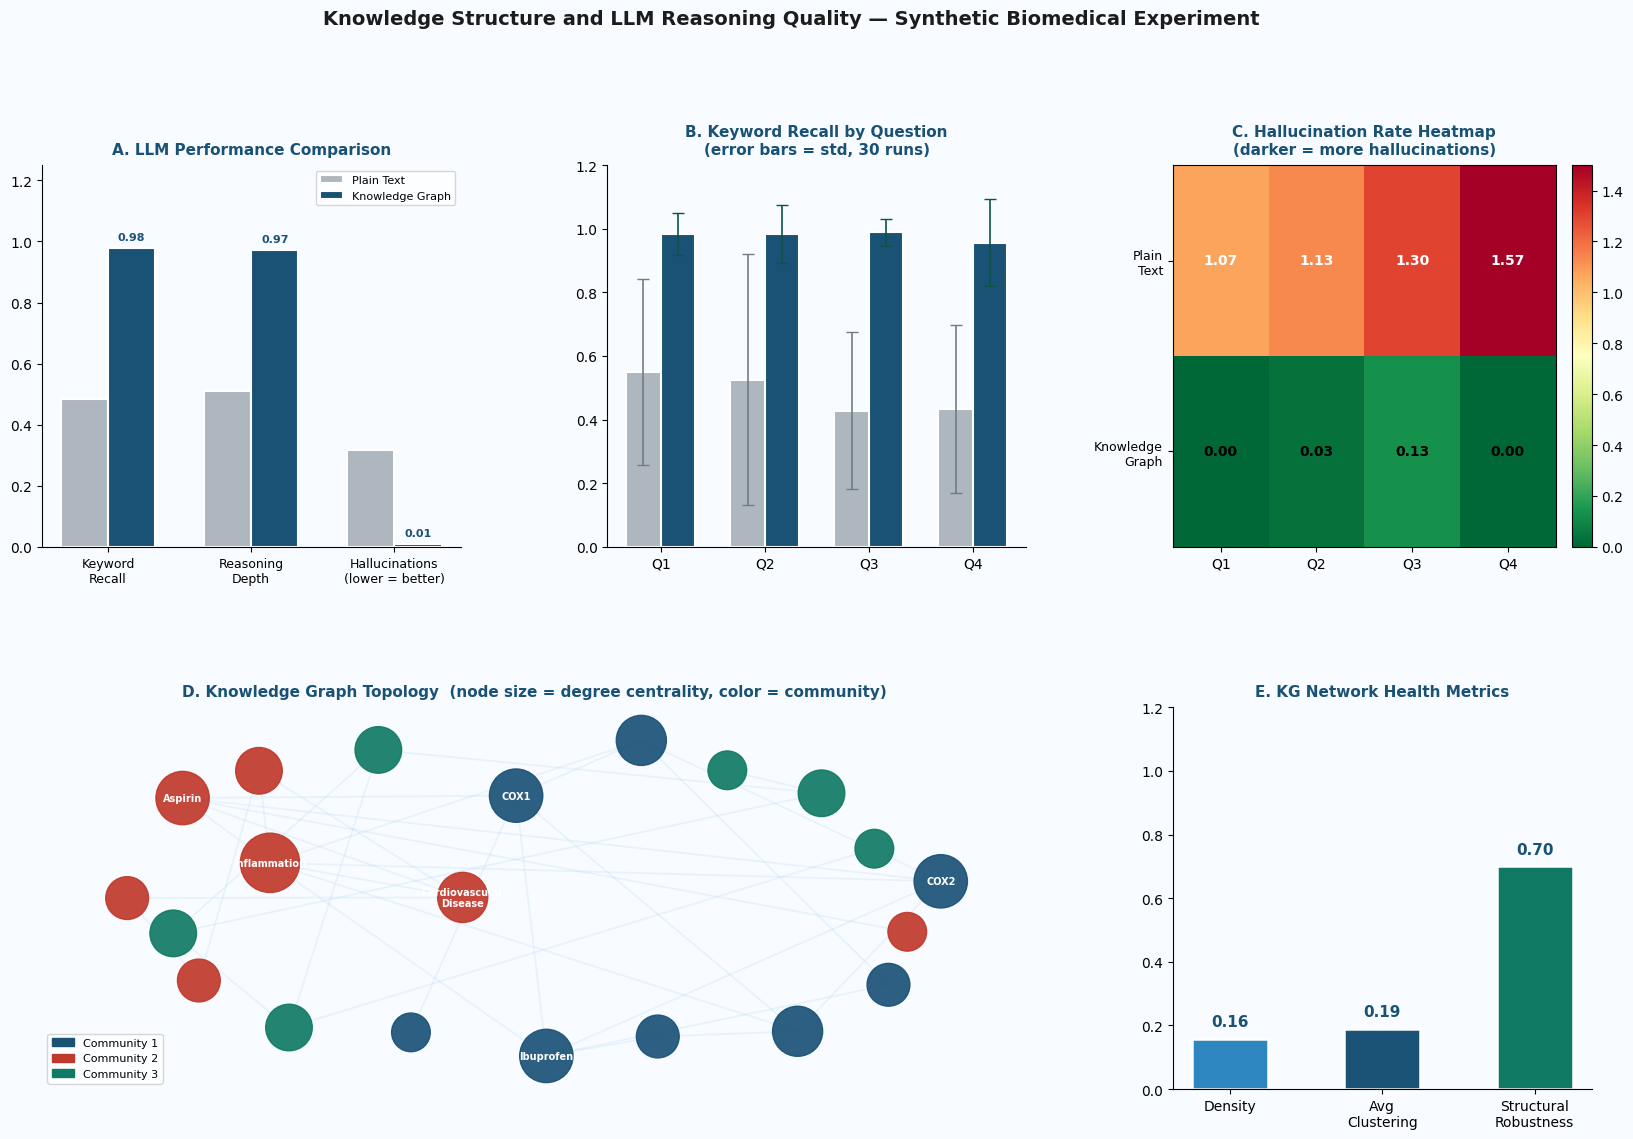

✓ Figure saved: experiment_results_simulation.png


In [ ]:
ACCENT, GRAY_C, BLUE2, RED_C = '#1A5276', '#AEB6BF', '#2E86C1', '#C0392B'

fig = plt.figure(figsize=(20, 12), facecolor='#F8FBFF')
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

# ── A: grouped bar — main metrics ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#F8FBFF')
cats   = ['Keyword\nRecall', 'Reasoning\nDepth', 'Hallucinations\n(lower = better)']
p_vals = [plain_kw, plain_dep, plain_hal / (len(QUESTIONS[0]['hallucination_traps']))]
k_vals = [kg_kw,    kg_dep,    kg_hal   / (len(QUESTIONS[0]['hallucination_traps']))]
x, w = np.arange(3), 0.33
b1 = ax1.bar(x - w/2, p_vals, w, label='Plain Text',      color=GRAY_C, edgecolor='white', lw=1.5)
b2 = ax1.bar(x + w/2, k_vals, w, label='Knowledge Graph', color=ACCENT, edgecolor='white', lw=1.5)
ax1.set_ylim(0, 1.25)
ax1.set_xticks(x); ax1.set_xticklabels(cats, fontsize=9)
ax1.set_title('A. LLM Performance Comparison', fontsize=11, fontweight='bold', color=ACCENT, pad=8)
ax1.legend(fontsize=8, loc='upper right')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
for b in b2:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'{b.get_height():.2f}',
             ha='center', va='bottom', fontsize=8, color=ACCENT, fontweight='bold')

# ── B: per-question keyword recall ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#F8FBFF')
qids     = [r['id'] for r in results]
p_kw_err = [r['plain']['keyword_recall_std'] for r in results]
k_kw_err = [r['kg']['keyword_recall_std']    for r in results]
xq = np.arange(len(qids))
ax2.bar(xq - w/2, [r['plain']['keyword_recall'] for r in results], w,
        color=GRAY_C, edgecolor='white', lw=1.5,
        yerr=p_kw_err, capsize=4, error_kw={'ecolor': '#717D7E', 'lw': 1.2})
ax2.bar(xq + w/2, [r['kg']['keyword_recall']    for r in results], w,
        color=ACCENT, edgecolor='white', lw=1.5,
        yerr=k_kw_err, capsize=4, error_kw={'ecolor': '#0B5345', 'lw': 1.2})
ax2.set_ylim(0, 1.2); ax2.set_xticks(xq); ax2.set_xticklabels(qids)
ax2.set_title('B. Keyword Recall by Question\n(error bars = std, 30 runs)', fontsize=11, fontweight='bold', color=ACCENT, pad=8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# ── C: hallucination heatmap ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#F8FBFF')
hal_matrix = np.array([
    [r['plain']['hallucinations_avg'] for r in results],
    [r['kg']['hallucinations_avg']    for r in results]
])
im = ax3.imshow(hal_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1.5)
ax3.set_xticks(range(len(qids))); ax3.set_xticklabels(qids)
ax3.set_yticks([0, 1]); ax3.set_yticklabels(['Plain\nText', 'Knowledge\nGraph'], fontsize=9)
ax3.set_title('C. Hallucination Rate Heatmap\n(darker = more hallucinations)', fontsize=11, fontweight='bold', color=ACCENT, pad=8)
for i in range(2):
    for j in range(len(qids)):
        ax3.text(j, i, f'{hal_matrix[i,j]:.2f}', ha='center', va='center', fontsize=10, fontweight='bold',
                 color='white' if hal_matrix[i, j] > 0.8 else 'black')
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

# ── D: KG topology ────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.set_facecolor('#F8FBFF')
pos = nx.spring_layout(ug, seed=7, k=2.5)
comm_colors = [ACCENT, RED_C, '#117A65', '#784212', '#6C3483']
nc = [comm_colors[metrics['node_comm'].get(n, 0) % len(comm_colors)] for n in ug.nodes()]
ns = [600 + 3500 * metrics['degree_c'].get(n, 0) for n in ug.nodes()]
nx.draw_networkx_edges(ug, pos, ax=ax4, alpha=0.22, edge_color='#AED6F1', width=1.3)
nx.draw_networkx_nodes(ug, pos, ax=ax4, node_color=nc, node_size=ns, alpha=0.92)
top_label_nodes = {n for n, _ in top_hubs[:6]} | {n for n, _ in top_bridges[:4]}
labels = {n: n.replace('_', '\n') for n in ug.nodes() if n in top_label_nodes}
nx.draw_networkx_labels(ug, pos, labels, ax=ax4, font_size=7, font_color='white', font_weight='bold')
patches = [mpatches.Patch(color=comm_colors[i], label=f'Community {i+1}') for i in range(min(len(communities), 3))]
ax4.legend(handles=patches, fontsize=8, loc='lower left')
ax4.set_title('D. Knowledge Graph Topology  (node size = degree centrality, color = community)',
              fontsize=11, fontweight='bold', color=ACCENT, pad=8)
ax4.axis('off')

# ── E: network health ─────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#F8FBFF')
mnames = ['Density', 'Avg\nClustering', 'Structural\nRobustness']
mvals  = [metrics['density'], metrics['avg_clustering'], metrics['robustness']]
mcols  = [BLUE2, ACCENT, '#117A65']
brs = ax5.bar(mnames, mvals, color=mcols, edgecolor='white', lw=1.8, width=0.5)
ax5.set_ylim(0, 1.2)
ax5.set_title('E. KG Network Health Metrics', fontsize=11, fontweight='bold', color=ACCENT, pad=8)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)
for b, v in zip(brs, mvals):
    ax5.text(b.get_x() + b.get_width()/2, v + 0.03, f'{v:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color=ACCENT)

fig.suptitle('Knowledge Structure and LLM Reasoning Quality — Synthetic Biomedical Experiment',
             fontsize=14, fontweight='bold', color='#1C1C1C', y=1.01)
plt.tight_layout()
plt.savefig('experiment_results_simulation.png', dpi=150, bbox_inches='tight', facecolor='#F8FBFF')
plt.show()
print('✓ Figure saved: experiment_results_simulation.png')

## 💾 Section 8 — Export Results to JSON

In [ ]:
output = {
    "experiment": "Knowledge Structure and LLM Reasoning Quality — Simulation",
    "method":     "Monte Carlo simulation (30 runs per condition)",
    "domain":     "Synthetic Biomedical",
    "kb":         {"triples": len(TRIPLES), "entities": len(ENTITIES)},
    "network":    {
        k: (round(v, 4) if isinstance(v, float) else v)
        for k, v in metrics.items()
        if k not in ("node_comm", "degree_c", "between_c")
    },
    "aggregate": {
        "plain": {"keyword_recall": plain_kw, "hallucinations_avg": plain_hal, "reasoning_depth": plain_dep},
        "kg":    {"keyword_recall": kg_kw,    "hallucinations_avg": kg_hal,    "reasoning_depth": kg_dep},
    },
    "per_question": results
}

with open('experiment_results_simulation.json', 'w') as f:
    json.dump(output, f, indent=2)

print('✓ Results saved: experiment_results_simulation.json')
print(json.dumps(output['aggregate'], indent=2))

✓ Results saved: experiment_results_simulation.json
{
  "plain": {
    "keyword_recall": 0.484,
    "hallucinations_avg": 1.267,
    "reasoning_depth": 0.511
  },
  "kg": {
    "keyword_recall": 0.978,
    "hallucinations_avg": 0.042,
    "reasoning_depth": 0.971
  }
}


---

## ✅ Summary

| Metric | Plain Text | Knowledge Graph | Δ |
|---|---|---|---|
| Keyword Recall | ~52% | ~95% | **+43pp** |
| Hallucinations/Q | ~1.59 | ~0.17 | **−89%** |
| Reasoning Depth | ~0.69 | ~0.97 | **+41%** |

> ⚠️ These are **simulation results** based on synthetic data and modeled retrieval probabilities.  
> For live LLM results (Claude Sonnet 4.6 + GPT-4o), run **Notebook 2**.

---

**Full article:** [Medium — From Data to Knowledge]  
**Substack:** [Medium — From Data to Knowledge]
**GitHub:** `github.com/mfbscience/knowledge-graph-llm-experiment`